In [2]:
%pip install numpy --upgrade

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 3.2 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/12.6 MB 3.0 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/12.6 MB 2.9 MB/s eta 0:00:04
   ---- ----------------------------------- 1.6/12.6 MB 2.3 MB/s eta 0:00:05
   ----- ---------------------------------- 1.8/12.6 MB 1.9 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.6 MB 1.6 MB/s eta 0:00:07
   ------- -------------------------------- 2.4/12.6 MB 1.6 MB/s eta 0:00:07
   ------- -------------------------------- 2.4/12.6 MB 1.6 MB/s eta 0:00:07
   -------- ------------------------------- 2.6/12.6 MB 1.4 MB/s eta 0:00:08
   --------- ------------------------------ 2.9/12.6 MB 1.3 MB/s eta 0:00:08
   --------- ------------------------------ 3.1/12.6 MB 1.4 MB/s eta 0:00:07
   --------- ------------------------------ 3.1/12.6 MB 1.4 MB/s eta 0:00:07
   ---

In [2]:
%pip install pandas --upgrade

   ---------------------------------------- 0.0/10.9 MB ? eta -:--:--
    --------------------------------------- 0.3/10.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/10.9 MB 3.8 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/10.9 MB 3.3 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/10.9 MB 2.9 MB/s eta 0:00:03
   --------- ------------------------------ 2.6/10.9 MB 2.5 MB/s eta 0:00:04
   ---------- ----------------------------- 2.9/10.9 MB 2.3 MB/s eta 0:00:04
   ----------- ---------------------------- 3.1/10.9 MB 2.3 MB/s eta 0:00:04
   -------------- ------------------------- 3.9/10.9 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 4.7/10.9 MB 2.6 MB/s eta 0:00:03
   ------------------- -------------------- 5.2/10.9 MB 2.6 MB/s eta 0:00:03
   --------------------- ------------------ 5.8/10.9 MB 2.6 MB/s eta 0:00:02
   ----------------------- ---------------- 6.3/10.9 MB 2.6 MB/s eta 0:00:02
   ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vectorbt 1.0.0 requires pandas<3.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


In [2]:
%pip install matplotlib --upgrade

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --upgrade --force-reinstall matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached numpy-2.4.6-cp314-cp314t-win_amd64.whl.metadata (6.6 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/8.4 MB 3.5 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.4 MB 3.7 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.4 MB 3.6 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.4 MB 3.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.4 MB 3.1 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.4 MB 3.0 MB/s eta 

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vectorbt 1.0.0 requires pandas<3.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


=== CÁLCULO DA CURVA DE CAPITAL (EQUITY CURVE) Mínima Variância ===
1. A carregar os históricos e taxas externas...
2. A calcular os rendimentos da estratégia...
3. A descontar a fricção do Turnover (com correção de borda)...
4. A renderizar a evolução do património...


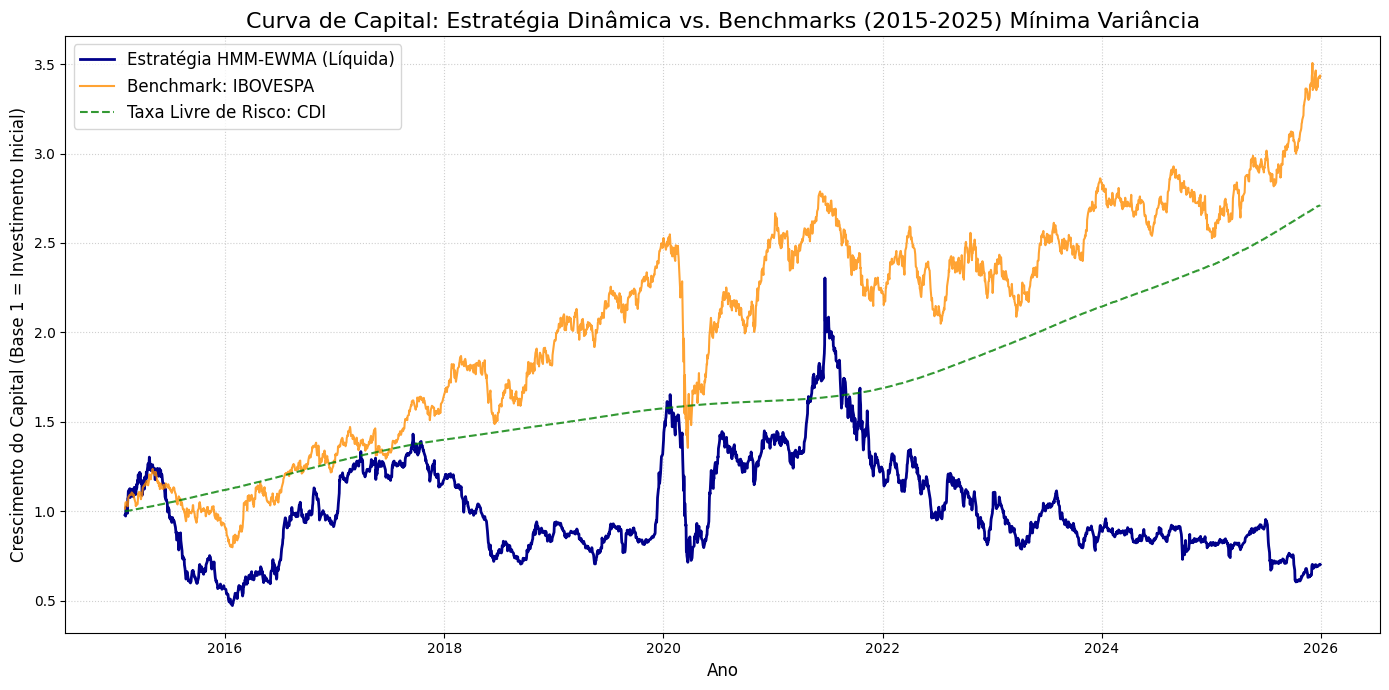


=== RESULTADO FINAL DO BACKTEST Mínima Variância ===
Período: 2015-01-31 a 2025-12-30
Rendimento Estratégia HMM: +-29.71%
Rendimento IBOVESPA:       +243.49%
Rendimento CDI:            +171.10%
Gráfico salvo em: C:\VSCodeWorkspace\TCC_Escrito\data\curva_capital_backtest_bl_hibrido.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def calcular_curva_capital(diretorio_dados):
    print("=== CÁLCULO DA CURVA DE CAPITAL (EQUITY CURVE) Mínima Variância ===")
    
    print("1. A carregar os históricos e taxas externas...")
    historico_pesos = pd.read_csv(os.path.join(diretorio_dados, "historico_alocacao_BlackLitterman_LSTM.csv"), index_col=0, parse_dates=True)
    df_retornos = pd.read_csv(os.path.join(diretorio_dados, "matriz_retornos_simples_v2.csv"), index_col='Data', parse_dates=True)
    historico_turnover = pd.read_csv(os.path.join(diretorio_dados, "historico_turnover_BL_LSTM.csv"), index_col=0, parse_dates=True)
    historico_turnover.columns = ['Turnover']
    
    # Carregamento Externo do CDI
    caminho_cdi = os.path.join(diretorio_dados, "CDI_2010_2026.xlsx")
    df_cdi = pd.read_excel(caminho_cdi)
    df_cdi = df_cdi.rename(columns={'Date': 'Data', 'valor': 'CDI'}).set_index('Data')
    df_cdi.index = pd.to_datetime(df_cdi.index)
    
    data_inicio = historico_pesos.index[0]
    df_retornos = df_retornos.loc[data_inicio:]
    
    pesos_diarios = historico_pesos.reindex(df_retornos.index).ffill()
    pesos_diarios = pesos_diarios.bfill() 
    
    print("2. A calcular os rendimentos da estratégia...")
    retornos_ativos = df_retornos[historico_pesos.columns]
    retorno_carteira_bruto = (retornos_ativos * pesos_diarios).sum(axis=1)
    
    print("3. A descontar a fricção do Turnover (com correção de borda)...")
    custo_transacional = 0.002 # 0.2%
    custos_diarios = pd.Series(0.0, index=retorno_carteira_bruto.index)

    # 1. Limpar possíveis NaTs que venham do CSV
    historico_turnover = historico_turnover[historico_turnover.index.notna()]

    # 2. CORREÇÃO DO CALENDÁRIO BLINDADA
    datas_validas = []
    for data in historico_turnover.index:
        if data in custos_diarios.index:
            datas_validas.append(data)
        else:
            # Tenta pegar o último dia útil ANTERIOR
            dias_anteriores = custos_diarios.index[custos_diarios.index <= data]
            if not dias_anteriores.empty:
                datas_validas.append(dias_anteriores.max())
            else:
                # Se não existir dia útil antes (início da base), pega o PRÓXIMO dia útil
                dias_posteriores = custos_diarios.index[custos_diarios.index >= data]
                if not dias_posteriores.empty:
                    datas_validas.append(dias_posteriores.min())
                else:
                    datas_validas.append(pd.NaT) # Fallback extremo

    # Atualiza o index
    historico_turnover.index = datas_validas
    historico_turnover = historico_turnover[historico_turnover.index.notna()] # Garante limpeza

    # Aplica o custo
    custos_diarios.loc[historico_turnover.index] = historico_turnover.iloc[:, 0] * custo_transacional

    retorno_carteira_liquido = retorno_carteira_bruto - custos_diarios    
    print("4. A renderizar a evolução do património...")
    curva_estrategia = (1 + retorno_carteira_liquido).cumprod()
    curva_ibov = (1 + df_retornos['IBOV']).cumprod()

    # Alinhar CDI com os retornos e gerar a curva limpa
    cdi_alinhado = df_cdi['CDI'].reindex(df_retornos.index).ffill()
    curva_cdi = (1 + cdi_alinhado).cumprod()
    
    plt.figure(figsize=(14, 7))
    plt.plot(curva_estrategia, label='Estratégia HMM-EWMA (Líquida)', color='darkblue', linewidth=2)
    plt.plot(curva_ibov, label='Benchmark: IBOVESPA', color='darkorange', linewidth=1.5, alpha=0.8)
    plt.plot(curva_cdi, label='Taxa Livre de Risco: CDI', color='green', linewidth=1.5, linestyle='--', alpha=0.8)
    
    plt.title('Curva de Capital: Estratégia Dinâmica vs. Benchmarks (2015-2025) Mínima Variância', fontsize=16)
    plt.ylabel('Crescimento do Capital (Base 1 = Investimento Inicial)', fontsize=12)
    plt.xlabel('Ano', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left', fontsize=12)
    plt.tight_layout()
    
    caminho_grafico = os.path.join(diretorio_dados, "curva_capital_backtest_bl_hibrido.png")
    plt.savefig(caminho_grafico, dpi=300)
    plt.show()
    
    retorno_total_est = (curva_estrategia.iloc[-1] - 1) * 100
    retorno_total_ibov = (curva_ibov.iloc[-1] - 1) * 100
    retorno_total_cdi = (curva_cdi.iloc[-1] - 1) * 100
    
    print("\n=== RESULTADO FINAL DO BACKTEST Mínima Variância ===")
    print(f"Período: {data_inicio.date()} a {curva_estrategia.index[-1].date()}")
    print(f"Rendimento Estratégia HMM: +{retorno_total_est:.2f}%")
    print(f"Rendimento IBOVESPA:       +{retorno_total_ibov:.2f}%")
    print(f"Rendimento CDI:            +{retorno_total_cdi:.2f}%")
    print(f"Gráfico salvo em: {caminho_grafico}")
    print("===================================")

pasta_dados = r"C:\VSCodeWorkspace\TCC_Escrito\data"
calcular_curva_capital(pasta_dados)